# Pangeo-Enabled ESM Pattern Scaling (PEEPS)
# libraries and helper functions

For simplicity in this notebook, many of the repeated calculations used for
linear pattern scaling are included as functions in the `helper.py` script,
which is a part of this repository and sourced:

In [253]:
# Load all of the libraries
from matplotlib import pyplot as plt
import pandas as pd
import os
import xarray as xr
import numpy as np
import sklearn as skl

import sys
sys.path.append("..")
import fxns


%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 12, 6

# easier to read displays in console
pd.set_option('display.max_columns', None)


# Prep where to write the processed data out to
DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(DATA_DIR+"field", exist_ok=True)
os.makedirs(DATA_DIR+"global", exist_ok=True)
os.makedirs(DATA_DIR+"beta", exist_ok=True)
os.makedirs(DATA_DIR+"intercept", exist_ok=True)
os.makedirs(DATA_DIR+"yhat", exist_ok=True)
os.makedirs(DATA_DIR+"error_metrics", exist_ok=True)
os.makedirs(DATA_DIR+"raw_data", exist_ok=True)



In [254]:
# Files that are going to be generated by this script...
tag = 'CanESM5_ssp585_r10i1p1f1n_npp'

field_ofile = DATA_DIR + "field/" + tag + "field.nc"
global_ofile = DATA_DIR + "global/" + tag + "global.nc"

d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

cell_area = xr.open_dataset(DATA_DIR+"raw-data/areacella/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")

land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_historical_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    


In [255]:
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}

In [256]:
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year

 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)

# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field = annual_monthly_rate * land_cell_area.values

##ACS ?


# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field = field * 1e-12
#np.nanmax(field.npp.values)

# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field.attrs["frequency"] = "year"
field.attrs["units"] = "Pg C"
field.to_netcdf(field_ofile, mode="w")

field

<xarray.Dataset> Size: 5MB
Dimensions:    (lat: 64, bnds: 2, lon: 128, time: 165)
Coordinates:
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    time_bnds  (time, bnds) object 3kB 1850-06-16 12:00:00 ... 2014-07-16 22:...
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * time       (time) object 1kB 1850-07-01 17:00:00 ... 2014-07-01 17:00:00
Dimensions without coordinates: bnds
Data variables:
    npp        (time, lat, lon) float32 5MB 3.529e-13 3.529e-13 ... nan nan
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [257]:
# The global values, for the carbon values this is going to be
# the global total, since we have already multiplied by the
# land area we do not need to do the weighting.
other_dims = set(field.dims) - {"time"} # define that will sum over every dim except time
global_ts = field.sum(other_dims, skipna=True)
global_ts.to_netcdf(global_ofile, mode='w')

global_ts

<xarray.Dataset> Size: 2kB
Dimensions:  (time: 165)
Coordinates:
  * time     (time) object 1kB 1850-07-01 17:00:00 ... 2014-07-01 17:00:00
Data variables:
    npp      (time) float32 660B 60.07 60.83 59.37 60.33 ... 84.34 83.75 82.41
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [258]:
# Linear Pattern Scaling Portion
# The times should align since we are originating from the same raw netcdf file
# although this is an assumption TODO don't rely on assumptions.
field_with_global = field.copy()
field_with_global["time"] = global_ts[VAR]


field_with_global


<xarray.Dataset> Size: 5MB
Dimensions:    (lat: 64, bnds: 2, lon: 128, time: 165)
Coordinates:
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    time_bnds  (time, bnds) object 3kB 1850-06-16 12:00:00 ... 2014-07-16 22:...
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
  * time       (time) float32 660B 60.07 60.83 59.37 60.33 ... 84.34 83.75 82.41
Dimensions without coordinates: bnds
Data variables:
    npp        (time, lat, lon) float32 5MB 3.529e-13 3.529e-13 ... nan nan
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [259]:
field_with_global = field_with_global.rename({VAR: "field"})

# Use the field with global time series to do the regression.
# Save the results.
reg = field_with_global.polyfit(dim="time", deg=1)

reg

<xarray.Dataset> Size: 133kB
Dimensions:                     (degree: 2, lat: 64, lon: 128)
Coordinates:
  * degree                      (degree) int64 16B 1 0
  * lat                         (lat) float64 512B -87.86 -85.1 ... 85.1 87.86
  * lon                         (lon) float64 1kB 0.0 2.812 ... 354.4 357.2
Data variables:
    field_polyfit_coefficients  (degree, lat, lon) float64 131kB 2.167e-14 .....
Attributes: (12/57)
    CCCma_model_hash:            55f484f90aff0e32c5a8e92a42c6b9ae7ffe6224
    CCCma_parent_runid:          rc3.1-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his10
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/230572bf-d227-4fb9-97a0-1df6b0b...
    variable_id:                 npp
    variant_label:               r10i1p1f1
    version:                     v20190429
    version_id:                  v20190429
    units:                       Pg C

In [260]:
beta = reg.field_polyfit_coefficients.sel(degree=1)
intercept = reg.field_polyfit_coefficients.sel(degree=0)

beta.to_netcdf(DATA_DIR + "beta/" + tag + "beta.nc", mode='w')
intercept.to_netcdf(DATA_DIR + "intercept/" + tag + "intercept.nc", mode='w')

# Beyond here are extra QAQC steps that will not be part of the formal pipeline.
# Pattern-scaled reconstruction
yhat = beta * global_ts + intercept
yhat = yhat.transpose(*("lat", "lon", "time"))
yhat.to_netcdf(DATA_DIR + "yhat/" + tag + "yhat.nc", mode='w')

# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...
# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = mse / var_obs
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

resid.to_netcdf(DATA_DIR + "error_metrics/" + tag + "resid.nc", mode='w')
mse.to_netcdf(DATA_DIR + "error_metrics/" + tag + "mse.nc", mode='w')
ns.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ns.nc", mode='w')
ct_bias.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctbias.nc", mode='w')
ct_var.to_netcdf(DATA_DIR + "error_metrics/" + tag + "ctvar.nc", mode='w')


/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


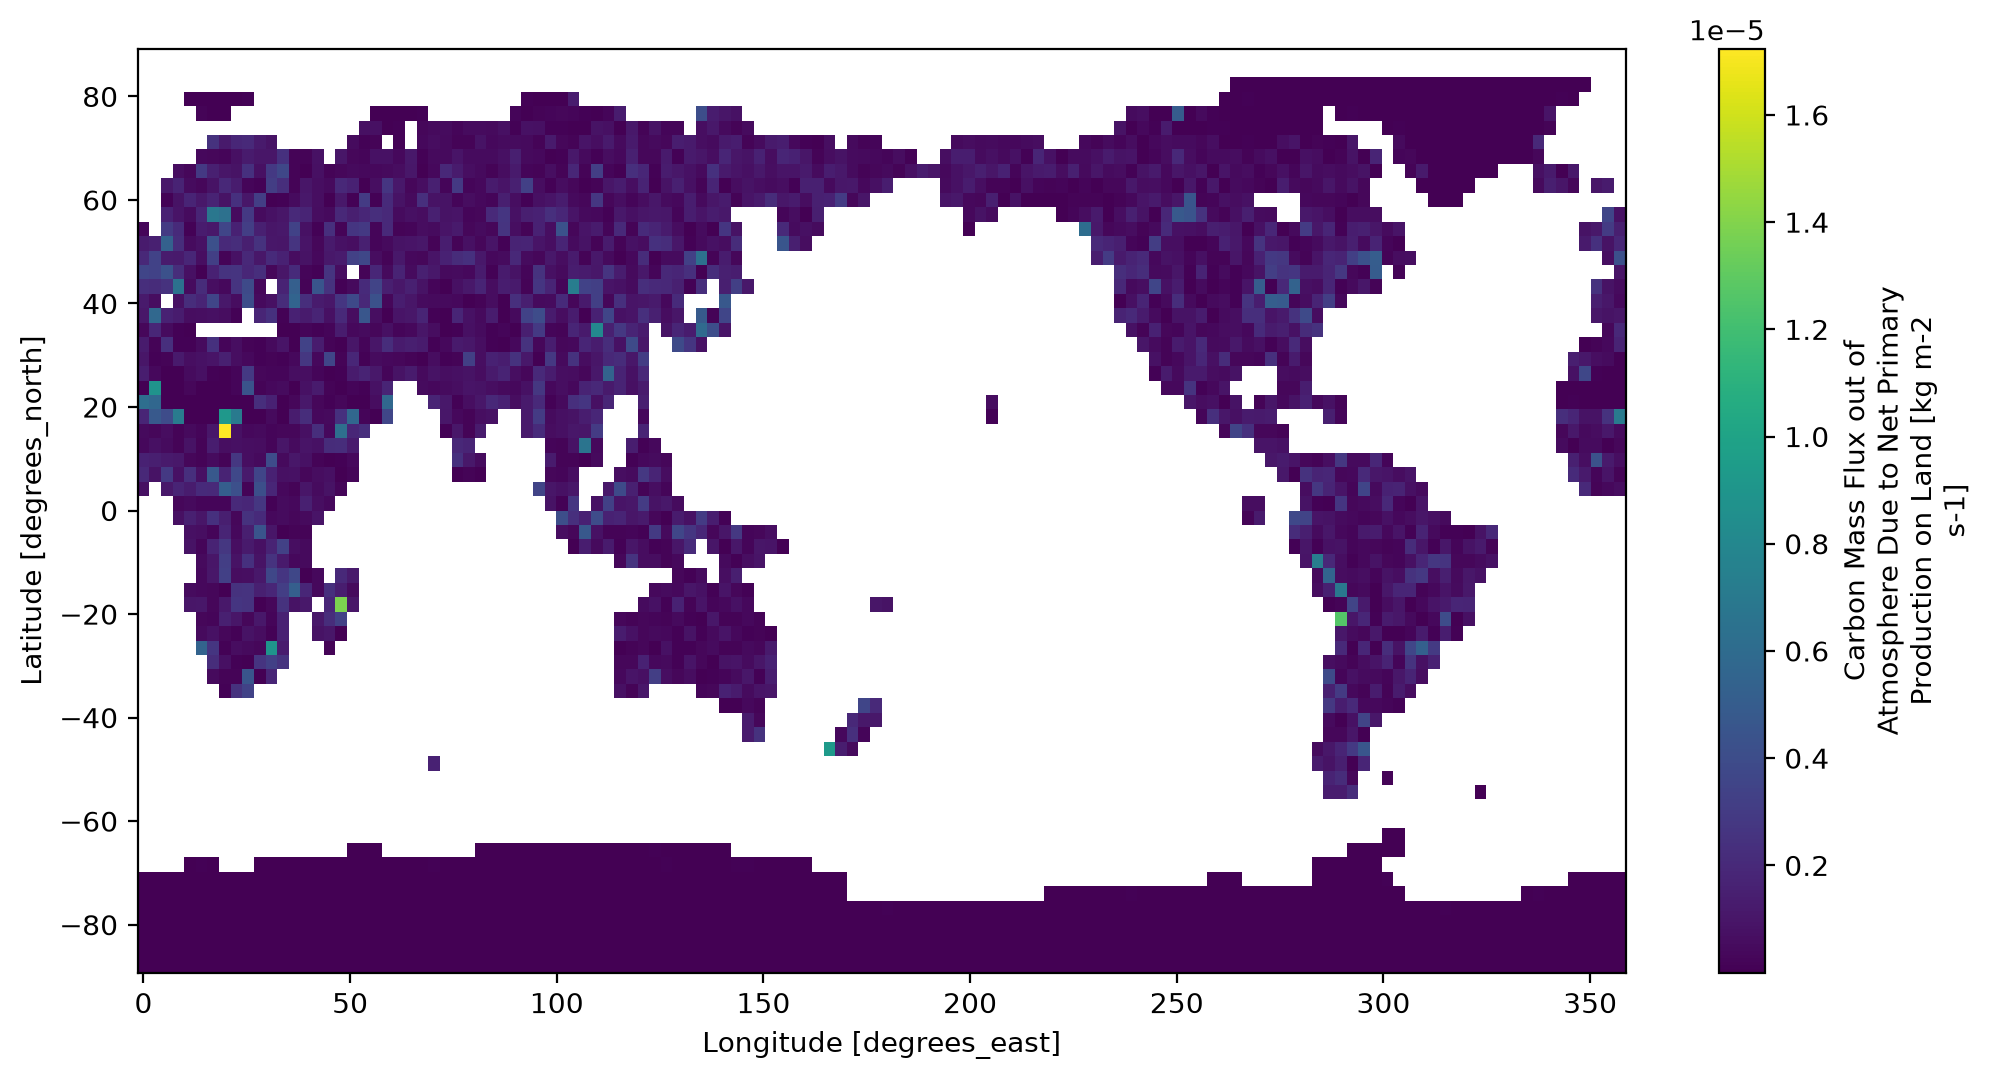

In [261]:
ct_bias.npp.plot()

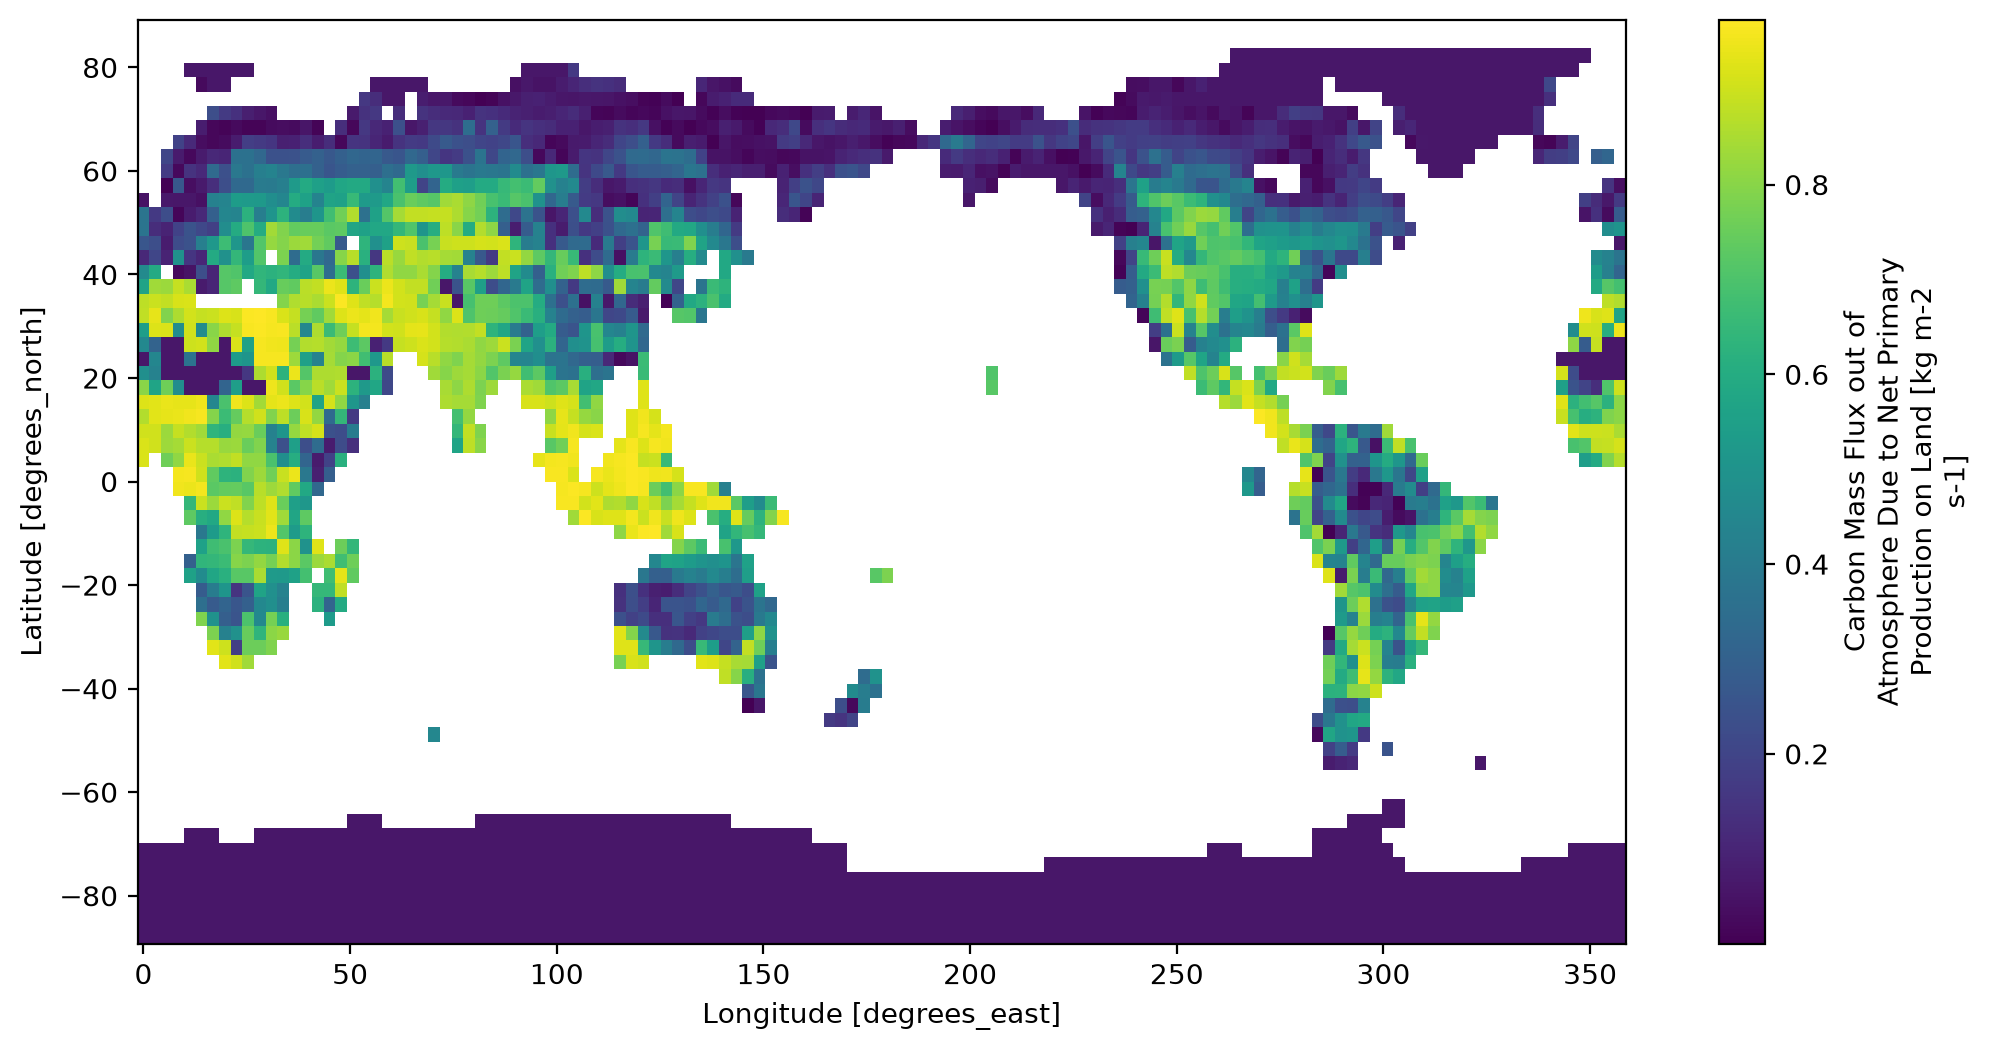

In [262]:
ct_var.npp.plot()

# Testing cross sample

## Idea 0 

use TGAV as one of the predictors. Pretty sure won't work because think not being able to use hist pattern to predict future means the patterns (parameters) are different at different temps. 



## Idea 1 

We have 1950-2014 pattern and 2015-2100 pattern from CanESM5.

What if we additionally interpolate from historical pattern params to future pattern params?

$ (int, beta)_t = t*(int,beta)_{hist} + (1-t) * (int, beta)_{585} $

So then we could take the pattern of how the historical pattern evolves over time from CanESM5 and 
apply to the historical pattern(s) from TRENDY.

- absolutely an assumption and there would be caveats eg we are specifcally applying the CanESM5 ssp585 time evolution to TRENDY historical because we can show for CanESM5 (other SSPs) that just using history to estimate 585 is wrong. 

- Don't see a way around extrapolating if we want to use TRENDY. But we could look at a couple ESMs and Scenarios 

- This would also essentially move things out of sync in the feedback. We'd be applying a 585 pattern to a hector trajectory that isn't necessarily getting to 585. 

- how much do the spatial patterns differ by ESM


/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


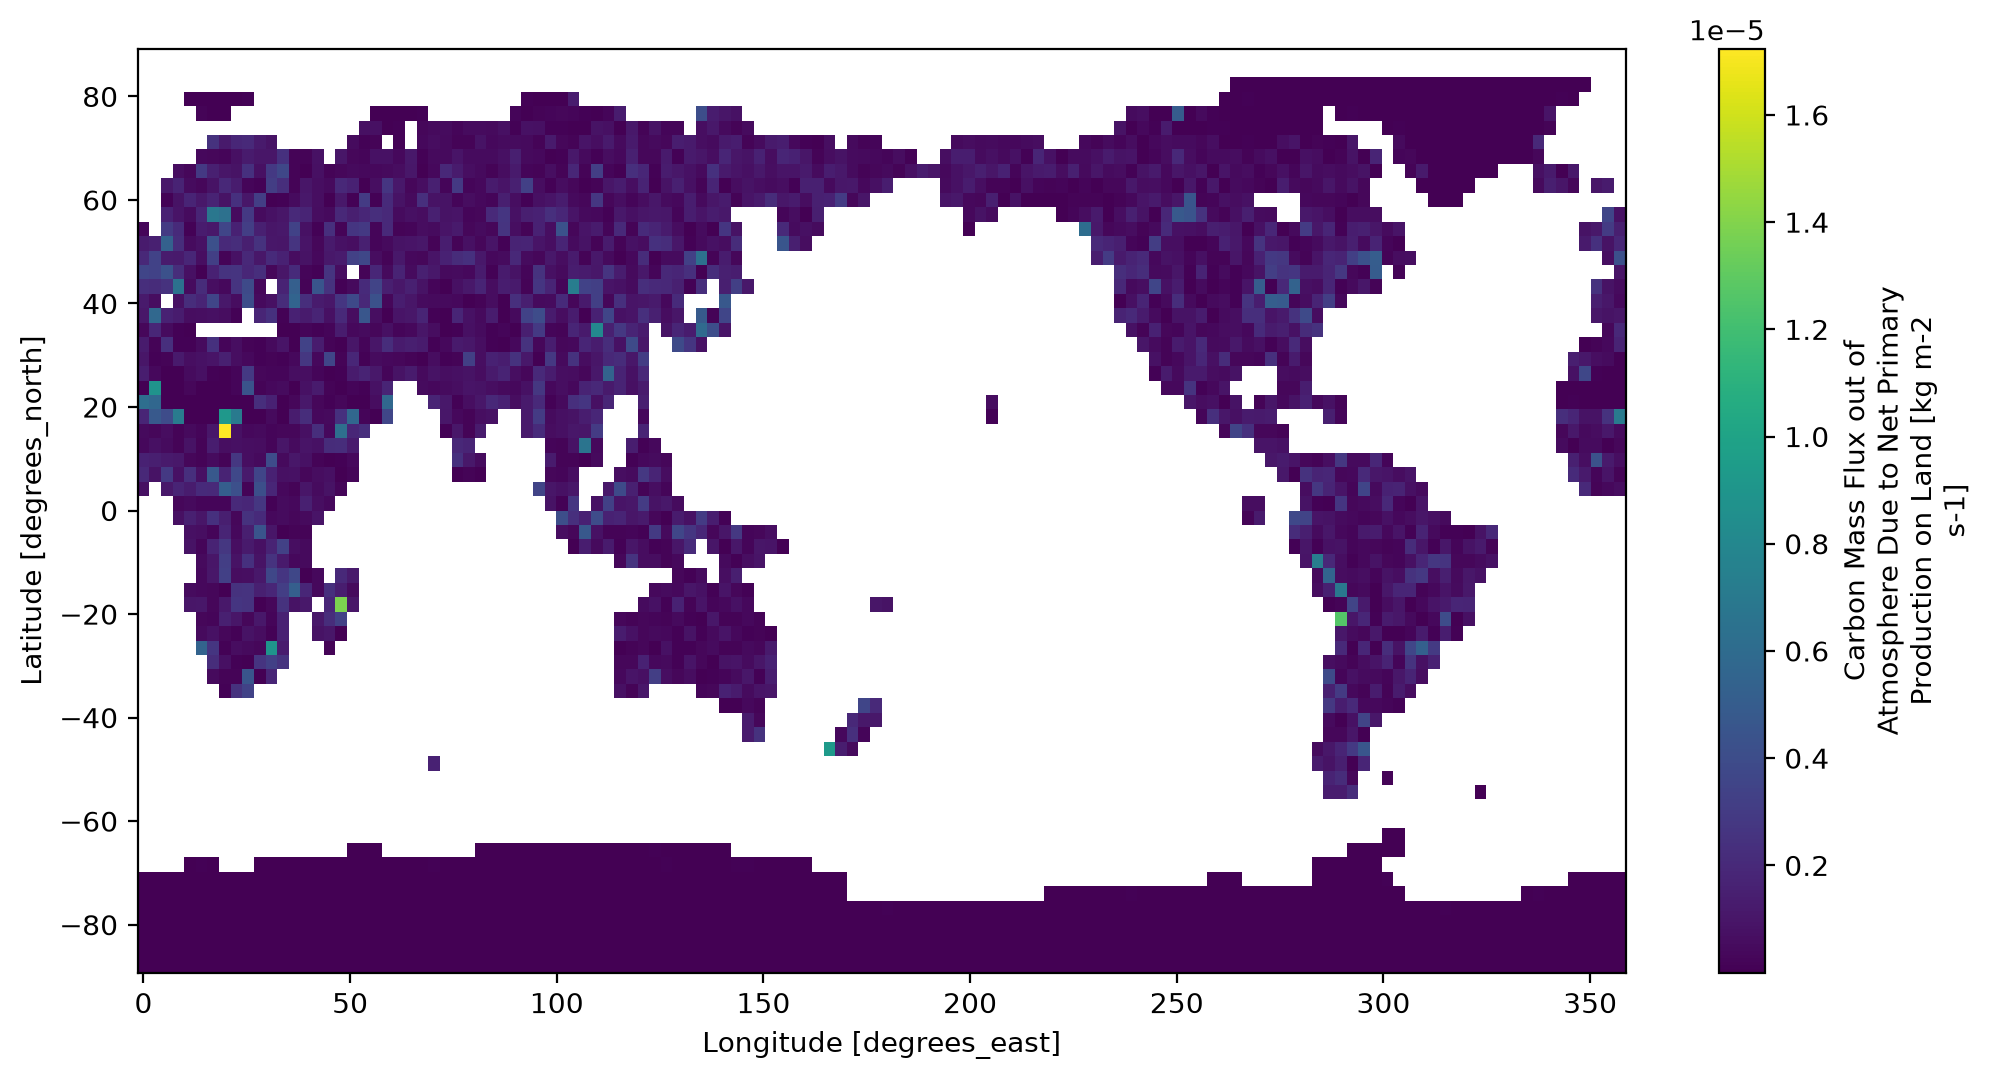

In [327]:
# Idea 0: historical pattern using GSAT as regressor, evaluate that pattern, then test that pattern on ssp585 data

# indep var
hist_gsat = pd.read_csv("cmip6_CMIP6_CMIP_CCCma_CanESM5_historical_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
global_xr = xr.Dataset({'GSAT': xr.DataArray(hist_gsat['value']-273.16,
                                             coords = [field['time']], 
                                             dims = ['time'])}) 
x = global_xr['GSAT'].values.reshape(-1,1)

# dependent var
testglobal = field.copy()
stacked = testglobal.stack(unifiedspatial=['lat', 'lon']).copy()
y = stacked[VAR].fillna(0).values


# do regression
linear_regressor = skl.linear_model.LinearRegression(fit_intercept = True)
linear_regressor.fit(x,y)

# shape params
tmp = linear_regressor.coef_.T
beta = xr.Dataset({'beta': xr.DataArray(linear_regressor.coef_.T, 
                                        coords = [['estimated_param'], stacked.unifiedspatial], 
                                        dims=['param', 'unifiedspatial'])}).unstack('unifiedspatial').copy()
intercept = xr.Dataset({'intercept': xr.DataArray(linear_regressor.intercept_.reshape(tmp.shape),
                                                   coords = [['estimated_param'], stacked.unifiedspatial], 
                                                   dims=['param', 'unifiedspatial'])}).unstack('unifiedspatial').copy()

yhat = beta['beta'] * global_xr['GSAT'] + intercept['intercept']
yhat = yhat.sel(param='estimated_param').drop_vars('param') .copy()
yhat = yhat.transpose(*("lat", "lon", "time")).rename(VAR).copy()


# evaluate this pattern
# Error metrics for quailty checks, these are going to tbe the most standardized versions.
# TODO this following chunk is part of the QAQC and will probably be removed from the formal pipeline
# TODO might want to consider masking out the 0s so that we don't run into issues with NAs, although
# that might be overkil...
# These are all our "insample" error metrics
var_obs = field.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat.var(dim="time") ** 0.5
mean_obs = field.mean(dim="time")
mean_sim = yhat.mean(dim="time")

resid = yhat - field
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

ct_bias.npp.plot()

/Users/snyd535/Documents/GitHub/bioeconomy_patternscaling/.venv/lib/python3.14/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


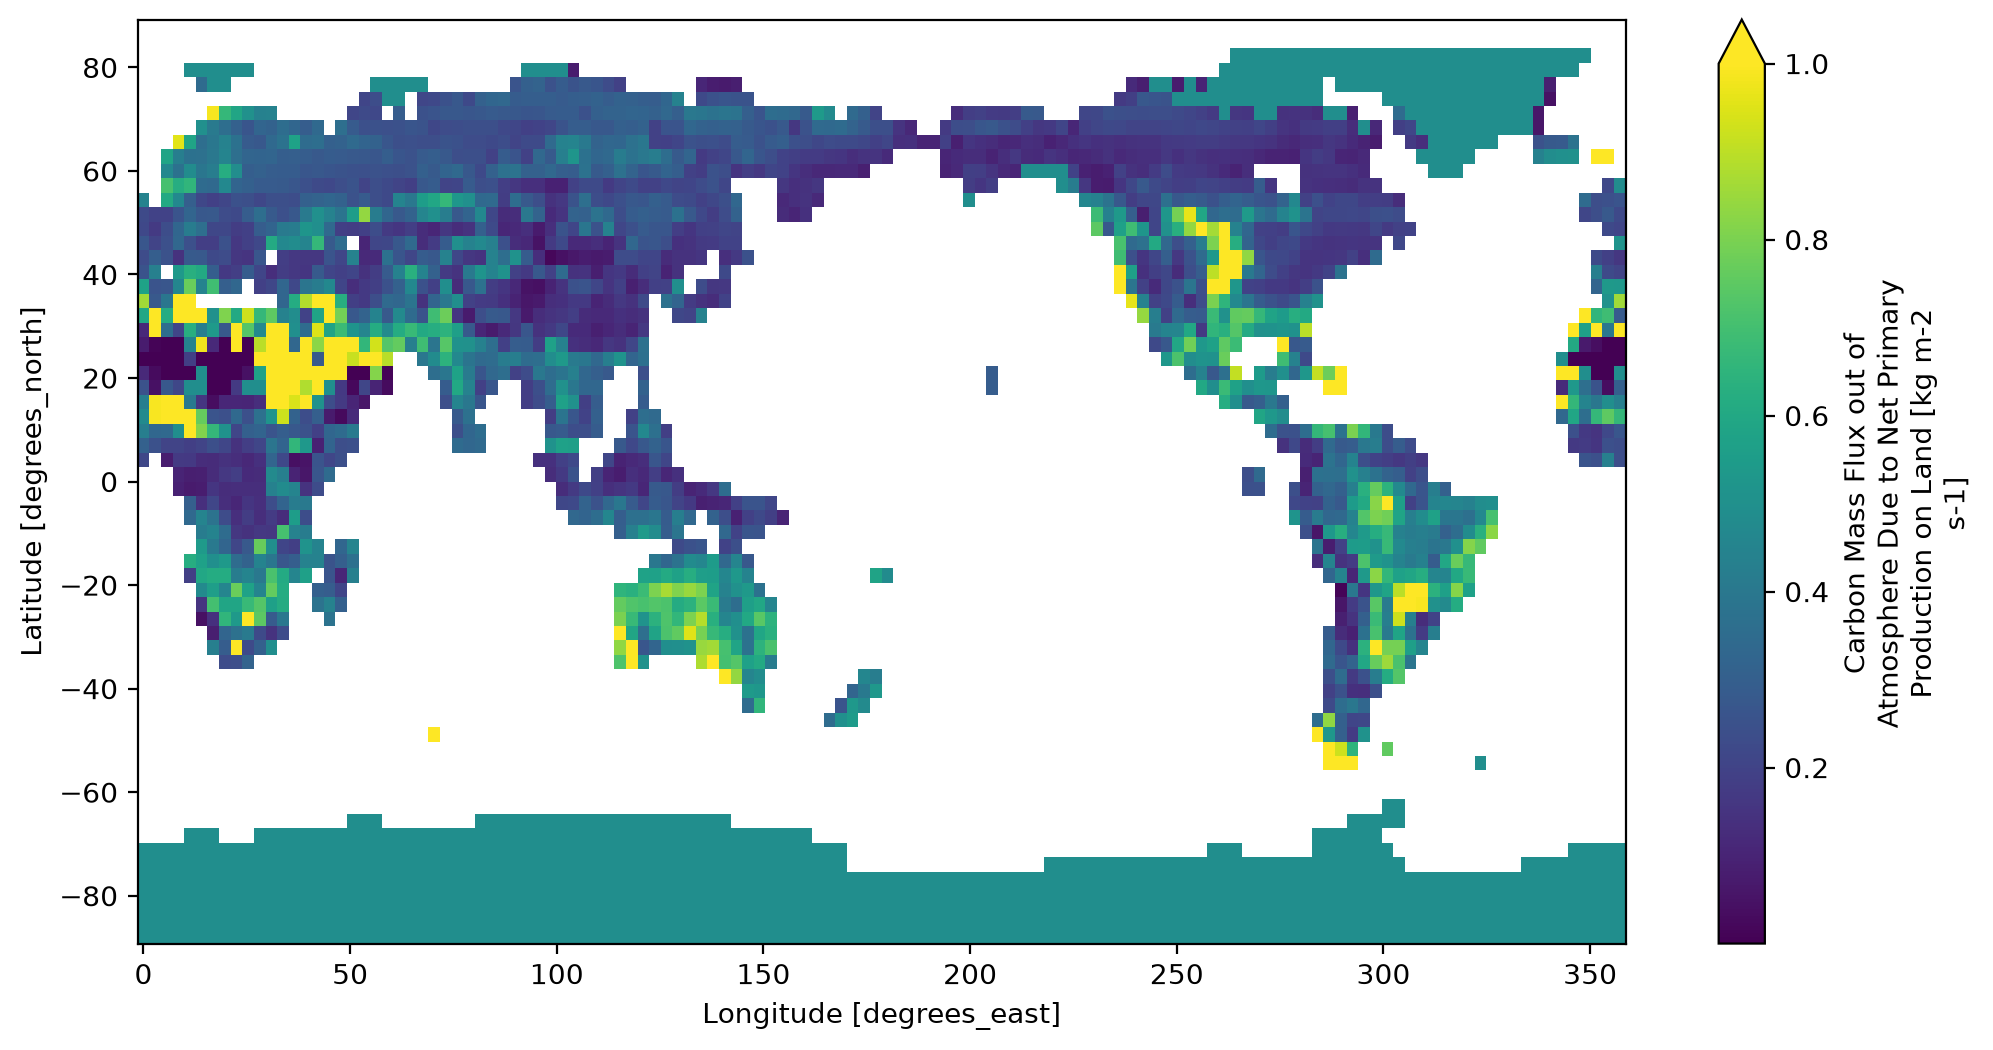

In [328]:
# apply pattern to SSP585 data
fut_gsat = pd.read_csv("cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
global_xr_fut = xr.Dataset({'GSAT': xr.DataArray(fut_gsat['value']-273.16,
                                             coords = [fut_gsat['year']], 
                                             dims = ['time'])}) 



yhat_fut = beta['beta'] * global_xr['GSAT'] + intercept['intercept']
yhat_fut = yhat_fut.sel(param='estimated_param').drop_vars('param') .copy()
yhat_fut = yhat_fut.transpose(*("lat", "lon", "time")).rename(VAR).copy()


# load and prep comparison data
d = xr.open_dataset(DATA_DIR+"raw-data/data/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
cell_area = xr.open_dataset("data/raw-data/areacella/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")
land_percent = xr.open_dataset(DATA_DIR+"raw-data/sftlf/CCCma_CanESM5_ssp585_r10i1p1f1_Lmon_npp_gn_v20190429_.nc")    
# Save meta data information
VAR = d.variable_id
all_attrs = d.attrs
original_units = d[VAR].units
keys_to_keep = ["variable_id", "variant_label", "experiment_id", "frequency", "grid_label", "source_id"]
meta_data = {k: all_attrs[k] for k in keys_to_keep if k in all_attrs}
# The first thing we need to do is get the annual field which should be total
# carbon content per year.
# TODO right now we are assuming a 365 day calander across models we may want to update this.
seconds_per_year = (365 * 24 * 60 * 60) / 12
annual_monthly_rate = d.coarsen(time=12).sum() * seconds_per_year
 # Calculate the land cell area, make sure that the land cell area where
# land is 0 assign it a na value so that
land_cell_area = cell_area.areacella * land_percent.sftlf * (1 / 100)
land_cell_area = land_cell_area.where(land_cell_area != 0, other=np.nan)
# Calculate the total annual carbon. Update attributes to reflect the
# new units.
# TODO figure out a way to add the attribtue information!
field_fut = annual_monthly_rate * land_cell_area.values
# Convert from kg of C to the Petagram of C which are the
# unites I am used to thinking in/hector units.
field_fut = field_fut * 1e-12
# annual_total_carbon = annual_total_carbon.assign_attrs()
# meta_data["frequency"] = "yr"
# meta_data["units"] = original_units.replace(" m-2 s-1", "")
# for k, v in meta_data.items():
#    annual_total_carbon.attrs[f"{k}"] = str(v)
field_fut.attrs["frequency"] = "year"
field_fut.attrs["units"] = "Pg C"

var_obs = field_fut.var(dim="time")
sd_obs = var_obs ** 0.5
sd_sim = yhat_fut.var(dim="time") ** 0.5
mean_obs = field_fut.mean(dim="time")
mean_sim = yhat_fut.mean(dim="time")

resid = yhat_fut - field
mse = (resid * resid).mean(dim="time")
ns = (mse / var_obs) ** 0.5
ct_bias = abs(mean_obs - mean_sim) / sd_obs
ct_var = sd_sim / sd_obs

ns.npp.plot(vmax =1) 


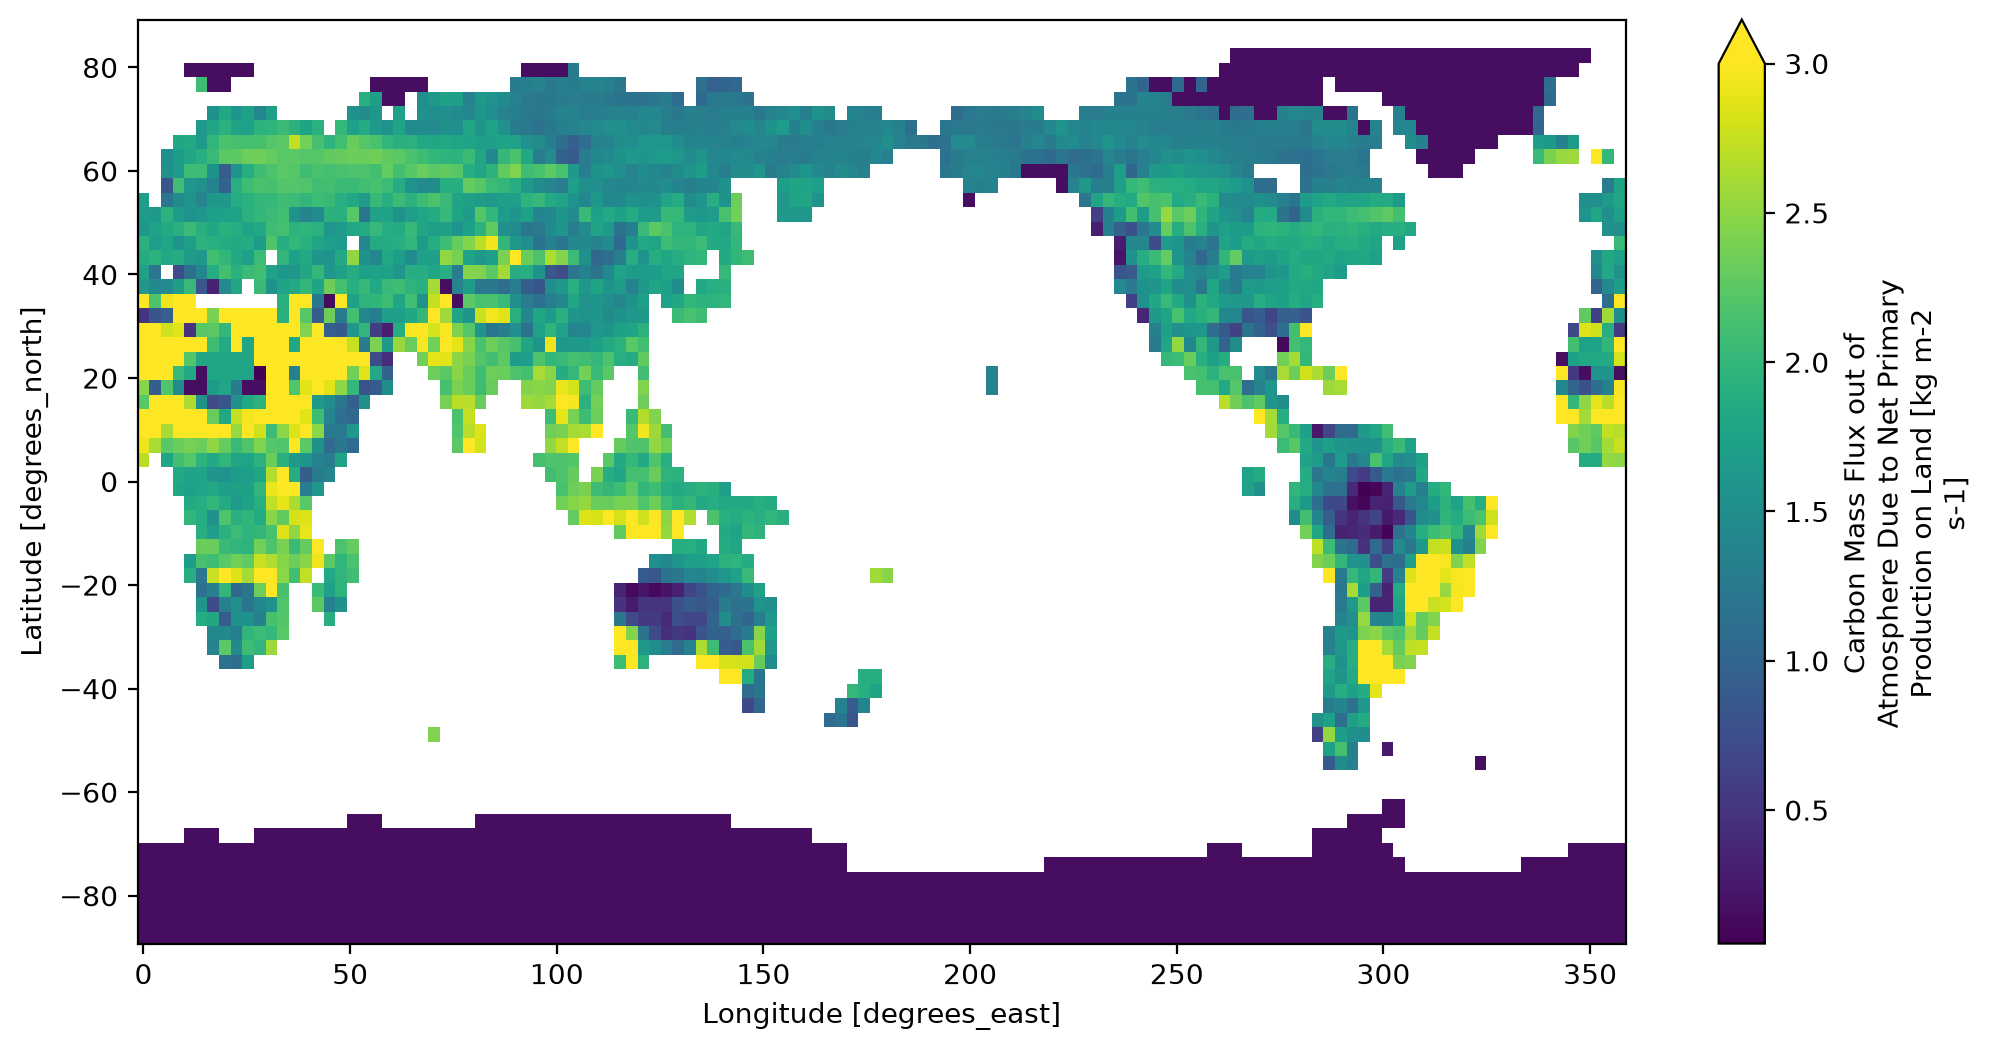

In [329]:
# continue evaluating - drop the one really bad grid cell so can see how things are elsewhere
ct_bias.npp.plot(vmax = 3)

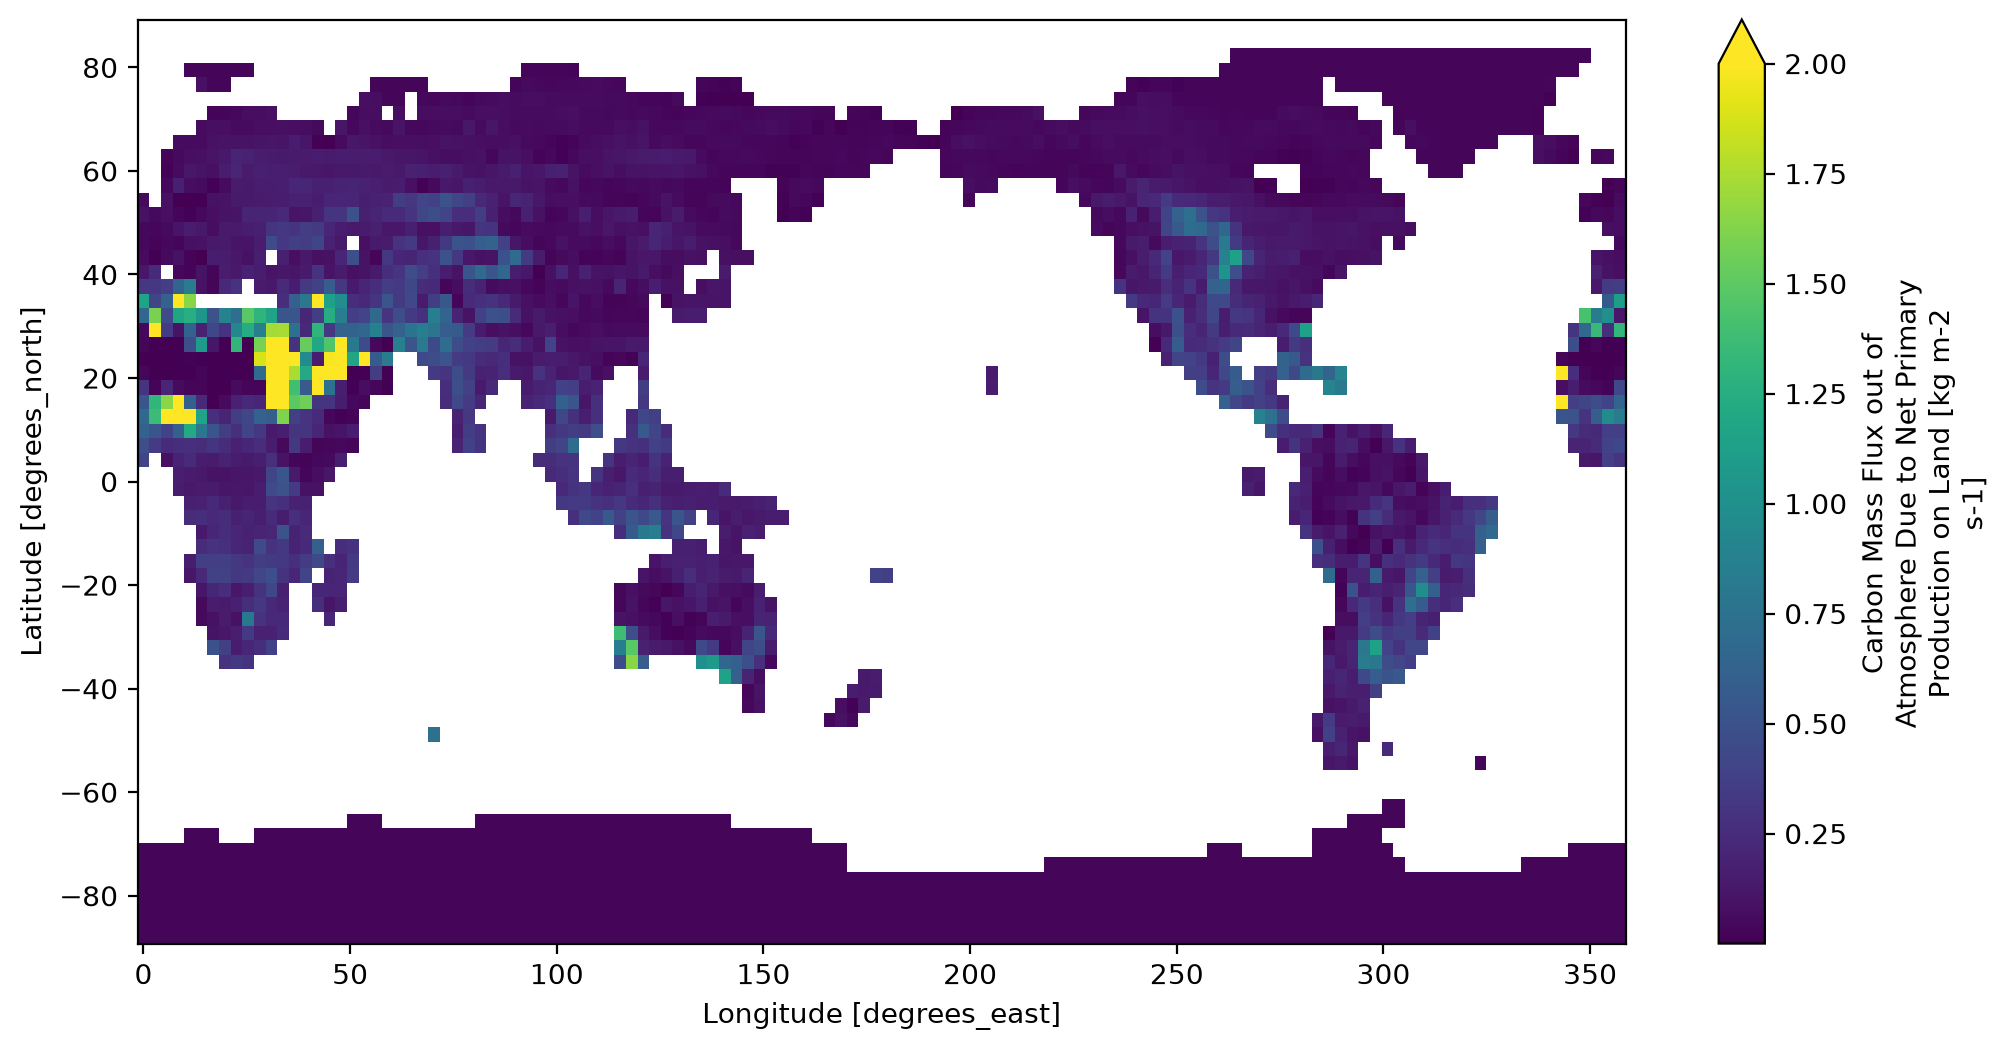

In [313]:
ct_var.npp.plot(vmax   = 2)

## Idea 2


Patterns by warming level (stitches inspired)


- Easy test: is Hector global NPP at +1deg the same whether that happens in 2070 or 2040? Assume not because history matters more in terrestrial: The running change in LUC from veg for NPP and soil temp for Rh may be enough to decouple from warming level.  

- Maybe decent actually based on below tests. Then the next step is to do the following including cross-check, because the spatial patterns might be different by scenario even for the same levels of warming.

But if somehow it does:

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from SSp585 by subsetting the SSP585 data to years where each warming level is that temperature change.

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from historical by subsetting the data to years where each warming level is that temperature change.

- learn the 0.5deg, 1 deg, 1.5 deg, etc patterns from SSP245 by subsetting the data to years where each warming level is that temperature change.

- cross check those SSP specific patterns to make sure they are just tied to warming level.

- learn the trendy historical patterns by warming level and apply them that way. 

- Caveat: the warming levels seen in TRENDY history won't be very broad. still have to figure out a way to extrapolate to higher levels to get to the future. At that point, gets ESM and SSP specific just like in Idea 1. 

- less issue of getting out of sync because we can just use Hector Tgav to pick which warming level pattern to use (independent of scenario).





- autoregressive won't work because will depend on not just time but land use at each time




In [ ]:
hector = pd.read_csv('hector_npp_rh_gsat_long.csv')

In [ ]:
### NBP is wrong, need hector runs for NPP and Rh separately but otherwise this is code
NPP = hector[hector.variable == "NPP"]
Rh = hector[hector.variable == "RH"]

gsat = hector[hector.variable == "global_tas"]

In [ ]:
f1 = gsat[gsat.value >= 1.5].copy()

f2 = f1[f1.value < 2.0].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

NPP['ids'] = NPP[['scenario']] + NPP[['year']].values.astype(str)


NPP[NPP['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say things are basically the same.

So NPP ranges 60-62.5 for warming between 1.5-2 for SSP126, 245, 370, 585, 460 aka not diagnostic or overshoot



In [ ]:
f1 = gsat[gsat.value >= 0.5].copy()

f2 = f1[f1.value < 0.7].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

NPP['ids'] = NPP[['scenario']] + NPP[['year']].values.astype(str)

NPP[NPP['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say t

In [ ]:
f1 = gsat[gsat.value >= 3.5].copy()

f2 = f1[f1.value < 3.75].copy()

f2['ids'] = f2[['scenario']] + f2[['year']].values.astype(str)

Rh['ids'] = Rh[['scenario']] + Rh[['year']].values.astype(str)

Rh[Rh['ids'].isin(f2['ids'])].groupby('scenario')['value'].mean() # key Q: is this ia meaningful range of values or can we say t

## Test it with patterns

In [ ]:
# bin GSAT
hist_gsat = pd.read_csv("cmip6_CMIP6_CMIP_CCCma_CanESM5_historical_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")
fut_gsat = pd.read_csv("cmip6_CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r10i1p1f1_Amon_tas_gn_v20190429_temp.csv")

In [ ]:
binsize = 0.25
binedges = np.arange(-1, 6, binsize)
binedges

hist_gsat['groups'] = pd.cut(hist_gsat['value'], bins=binedges, right=False)
hist_gsat.head()